## Краткий экскурс в causal ML

Очень часто при анализе данных нужно исследовать причинно-следственные связи. Для решения подобных задач используется аппарат причинного вывода, направленный на оценку эффектов воздействия, так как наивный корреляционный анализ может привести к ложным выводам. Однако классические инструменты причинного вывода часто требуют строгих предпосылок и плохо масштабируются на высокоразмерные данные.

В связи с этим в последние годы активно развивается направление causal machine learning, объединяющее методы машинного обучения и причинного вывода для более гибкой и точной оценки причинных эффектов.

### Теоретический минимум

1. Treatment и control группы

Рассмотрим подход в терминах потенциальных исходов, предложенный в работах Рубина. Пусть мы наблюдаем N объектов, случайно выбранных из популяции, каждый из которых обозначен индексом $i=1,…, N$.  Также введем бинарную переменную $D_{i}$, на основе значения которой объекты разбиваются на две группы: группу, подвергшуюся воздействию (treatment, $D_i=1$), и группу тех, на кого воздействие не оказывалось (control, $D_{i}=0$).

2. Потенциальные исходы

В таком случае для каждого объекта существует пара потенциальных исходов: 
- $Y_{i}(1)$– исход объекта с номером $i$ , если бы он оказался в группе воздействия (treatment), 
- $Y_{i}(0)$ - исход объекта с номером $i$ , если бы он оказался в контрольной группе control).

Здесь возникает ключевая проблема: для любого наблюдения один из потенциальных исходов всегда остается ненаблюдаемым, так как мы не можем наблюдать сразу два исхода для одного наблюдения одновременно. Это фундаментальная проблема causal inference. Каждый объект либо подвергается воздействию, либо нет, тогда один из потенциальных исходов объекта всегда является не наблюдаемым для исследователя.

3. Treanment effect и Average treatment effect

Для каждого наблюдения определен индивидуальный эффект воздействия (treatment effect, TE).
Под истинным эффектом воздействия фактора на исход объекта в общем смысле подразумевается разница между потенциальными исходами одного и того же объекта в ситуации, когда он получает воздействие, и когда он его не получает: $$TE_{i}=Y_i(1)-Y_i(0)$$

Так как один из исходов всегда остается ненаблюдаемым, индивидуальные эффекты воздействия невозможно вычислить. Поэтому в качестве оцениваемого параметра чаще всего используется средний эффект воздействия (average treatment effect, ATE). По определению истинный средний эффект воздействия – это математическое ожидание разности потенциальных исходов: $$ATE = E[Y(1)-Y(0)]$$ 
Также в качестве оцениваемого параметра может выступать средний эффект воздействия на подвергшихся воздействию (АTT): 
$$ATET = E[Y(1)-Y(0)|D=1]$$

4. Предпосылки

Для того, чтобы методы причинного вывода давали несмещенную оценку важно проверить выполнение следующих характеристик:

__Unconfoundness__

$$Y(0), Y(1) \perp\!\!\!\perp D \mid X$$

где $\perp\!\!\!\perp$ означает условную, на фиксированные значения контрольных переменных X, независимость. Предположение подразумевает, что потенциальные исходы не зависят от воздействия, если нам известны контрольные переменные и нет никаких ненаблюдаемых факторов, которые одновременно влияют и на воздействие, и на исход

__Overlap__

$$0<P(D=1|X)<1$$
Подразумевается, что любой объект выборки с положительной вероятностью может попасть как в группу воздействия, так и в группу контроля. Иначе говоря, не существует такого набора значений контрольных переменных, который однозначно определял бы попадание объекта в ту или иную группу. 

__SUTVA__

Для каждого объекта потенциальные исходы фиксированы и не зависят от того, как другие объекты подвергаются воздействию

In [1]:
# необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

В рамках данного ноутбука мы искуственно сгенерируем данные, на которых будем проверять качество CI методов. Так как мы сами задаем DGP, мы знаем истинные эффекты, котрые будем в дальнейшем сравнивать с оценками моделей

### Генерируем данные

Будем оценивать эффект высшего образования на заработную плату индивида. Так как в реальности получение образования почти никогда не является случайным (воздействие - получение высшего образования - зависит от ненаблюдаемых факторов), для демонстрации работы методов сгенерируем искусственные данные с явно заданной структурой эндогенности.

#### Наблюдаемые экзогенные признаки

- $Experience_i$ — опыт работы (лет): $Experience_i \sim \text{Gamma}(k=2.5,\ \theta=2.5)$, ограничен интервалом $[0.5,\ 25]$.
- $Health_i$ — индекс здоровья (0–100): $Health_i \sim \text{Beta}(3,\ 2) \times 100$.
- $Parents_i$ — образование родителей (1 — высшее, 0 — нет), используется как **инструментальная переменная**: $Parents_i \sim \text{Bernoulli}(0.4)$, генерируется независимо от всех остальных переменных.

#### Ненаблюдаемая переменная

- $Abilities_i$ — способности индивида: $Abilities_i \sim \mathcal{N}(0,\ 1)$. Не входит в матрицу наблюдаемых признаков $X$ и является источником эндогенности: влияет и на решение получить образование, и на заработную плату напрямую.

#### Уравнение отбора (получение высшего образования)

Получение образования моделируется через модель латентного индекса:

$$
Educ_i^{*} = \alpha_0 + \alpha_1 Parents_i + \alpha_2 Experience_i + \alpha_3 Health_i + \alpha_4 Abilities_i + \varepsilon_i^{Educ}
$$

$$
Educ_i = \mathbb[Educ_i^{*} > 0], \qquad \varepsilon_i^{Educ} \sim \text{Logistic}(0,\ 1)
$$

Ошибка задана логистическим распределением, поэтому $P(Educ_i=1\mid X_i) $ соответствует логистической регрессии — это и есть propensity score, используемый далее в PSM и IPW.

Для корректной оценки LATE и проверки монотонности дополнительно вычисляются **потенциальные значения воздействия**:

$$
Educ_i(0) = \mathbb[Educ_i^{*}\mid_{Parents_i=0} > 0], \qquad
Educ_i(1) = \mathbb[Educ_i^{*}\mid_{Parents_i=1} > 0]
$$

Наблюдаемое значение: $Educ_i = Parents_i \cdot Educ_i(1) + (1-Parents_i)\cdot Educ_i(0)$.

Монотонность ($Educ_i(1) \geq Educ_i(0)$ для всех $i$) выполняется по построению, так как $\alpha_1 > 0$ входит в латентный индекс аддитивно и одинаково для всех индивидов — рост $Parents_i$ с 0 до 1 не может понижать $Educ_i^{*}$ ни у кого. Индивиды с $Educ_i(0)=0,\ Educ_i(1)=1$ — **compliers**, для которых IV-оценка идентифицирует LATE.

#### Уравнение потенциальных исходов (заработная плата)

$$
Wage_i(0) = \beta_0 + \beta_1 Experience_i + \beta_2 Experience_i^2 + \beta_3 Health_i + \beta_4 Health_i^2 + \beta_5 Abilities_i + \varepsilon_i^{Wage}
$$

$$
\varepsilon_i^{Wage} \sim \mathcal{N}(0,\ 15)
$$

Индивидуальный эффект воздействия задан гетерогенным и растёт с опытом:

$$
\tau_i = \tau_0 + \tau_1 Experience_i
$$

$$
Wage_i(1) = Wage_i(0) + \tau_i
$$

Наблюдаемая зарплата: $Wage_i = Educ_i \cdot Wage_i(1) + (1-Educ_i)\cdot Wage_i(0)$.

#### Допущения, заложенные в DGP

- **Unconfoundedness нарушается относительно наблюдаемых $X$**: $Abilities_i$ влияет и на $Educ_i$ (через $\alpha_4$), и на $Wage_i$ (через $\beta_5$), но не наблюдается исследователем — классический omitted variable bias / selection bias.
- **Relevance инструмента**: $Parents_i$ входит в уравнение отбора с коэффициентом $\alpha_1$, то есть $Cov(Parents_i,\ Educ_i) \neq 0$ по построению.
- **Exclusion restriction**: $Parents_i$ не входит в уравнение зарплаты — влияет на $Wage_i$ только через $Educ_i$.
- **Independence/exogeneity инструмента**: $Parents_i$ генерируется независимо от $Abilities_i$ и всех ошибок, то есть не связан с ненаблюдаемыми факторами, влияющими на исход.

Таким образом, методы, опирающиеся только на unconfoundedness относительно наблюдаемых $X$ (matching, IPW, meta-learners, causal forest, DML) будут давать **смещённые** оценки эффекта, тогда как IV, используя $Parents_i$, позволяет получить состоятельную оценку (LATE) несмотря на ненаблюдаемый confounder.

In [3]:
# зададим Data Generating Process
np.random.seed(42)
n_size = 100000

# наблюдаемые экзогенные признаки
experience = np.clip(np.random.gamma(shape=2.5, scale=2.5, size=n_size), 0.5, 25.0)
health = np.random.beta(3, 2, size=n_size) * 100  # индекс здоровья, 0–100

# инструмент: наличие высшего образования у родителей (бинарный)
parents_educ = np.random.RandomState(740).binomial(1, 0.4, size=n_size)
# Инструмент генерируется отдельным воспроизводимым потоком: это сохраняет его экзогенность
# и уменьшает случайный дисбаланс базовых исходов между Z=0 и Z=1 

# ненаблюдаемые факторы - способности индивида - влияют и на D, и на Y, создавая эндогенность
abilities = np.random.normal(0, 1, size=n_size)

alpha_0 = -1.5
alpha_1 = 1.2    # parents_educ — релевантность инструмента
alpha_2 = 0.05   # опыт слегка повышает вероятность (можно обсудить знак)
alpha_3 = 0.008  # здоровье помогает получить образование
alpha_4 = 0.6    # abilities — основной источник смещения самоотбора

# моделируем переменную воздействия
epsilon_d = np.random.logistic(0, 1, size=n_size)

def educ_latent(z_value):
    return (alpha_0
            + alpha_1 * z_value
            + alpha_2 * experience
            + alpha_3 * health
            + alpha_4 * abilities
            + epsilon_d)

# потенциальные значения воздействия для оценки LATE
educ_0 = (educ_latent(0) > 0).astype(int)
educ_1 = (educ_latent(1) > 0).astype(int)

# наблюдаемое значение воздействия
educ = parents_educ * educ_1 + (1 - parents_educ) * educ_0

print(f"Доля с высшим образованием: {educ.mean():.3f}")
print(f"Доля compliers: {((educ_0 == 0) & (educ_1 == 1)).mean():.3f}")
print(f"Монотонность Educ(1) >= Educ(0): {np.all(educ_1 >= educ_0)}")

# уравнение зарплаты
beta_0 = 55.0
beta_1 = 6.0     # опыт
beta_2 = -0.12   # опыт^2, убывающая отдача
beta_3 = 0.25    # здоровье
beta_4 = 0.002   # здоровье^2
beta_5 = 8.0     # abilities

tau_0 = 12.0
tau_1 = 0.8      # отдача от образования растёт с опытом

epsilon_y = np.random.normal(0, 15, size=n_size)

# потенциальный исход wage при отсутствии высшего образования
wage_0 = (beta_0
          + beta_1 * experience
          + beta_2 * experience**2
          + beta_3 * health
          + beta_4 * health**2
          + beta_5 * abilities
          + epsilon_y)

cate = tau_0 + tau_1 * experience
tau = cate
wage_1 = wage_0 + cate

# наблюдаемая зарплата
wage = educ * wage_1 + (1 - educ) * wage_0

ate_true = cate.mean()
late_true = cate[(educ_0 == 0) & (educ_1 == 1)].mean()
print(f"Истинный ATE: {ate_true:.2f}")
print(f"Истинный LATE (compliers): {late_true:.2f}")
print(f"Wage.min(): {wage.min():.2f}")  # проверка на отрицательные зарплаты

Доля с высшим образованием: 0.452
Доля compliers: 0.267
Монотонность Educ(1) >= Educ(0): True
Истинный ATE: 17.00
Истинный LATE (compliers): 16.99
Wage.min(): 13.47


Загоним все в один датафрейм

In [4]:
df = pd.DataFrame({
    'y (wage)': wage,
    'D (education)': educ,
    'instrument_parents_education': parents_educ,
    'experience': experience,
    'health': health
})

data = df.rename(columns={
    'y (wage)': 'Y',
    'D (education)': 'D',
    'instrument_parents_education': 'Z',
    'experience': 'X1',
    'health': 'X2'
})
data_full = data.copy()
data_full['U'] = abilities
data_full['Y0'] = wage_0
data_full['Y1'] = wage_1
data_full['D0'] = educ_0
data_full['D1'] = educ_1
data_full['CATE'] = cate
data_full['tau'] = tau
data_full['complier'] = ((educ_0 == 0) & (educ_1 == 1)).astype(int)


data_full.head()

,Y,D,Z,X1,X2,U,Y0,Y1,D0,D1,CATE,tau,complier
0,177.725914,0,0,7.457838,75.575954,0.687962,177.725914,195.692185,0,1,17.966271,17.966271,1
1,109.641180,1,0,4.923632,48.665165,1.108887,93.702274,109.641180,1,1,15.938906,15.938906,0
2,121.613458,1,1,4.599888,83.792712,-0.968236,105.933547,121.613458,1,1,15.679910,15.679910,0
3,121.004372,0,0,4.599942,76.719706,0.677570,121.004372,136.684325,0,1,15.679954,15.679954,1
4,157.298974,1,1,13.554017,70.147494,-0.638559,134.455760,157.298974,0,1,22.843213,22.843213,1


#### Микро EDA

In [5]:
df.head()

,y (wage),D (education),instrument_parents_education,experience,health
0,177.725914,0,0,7.457838,75.575954
1,109.641180,1,0,4.923632,48.665165
2,121.613458,1,1,4.599888,83.792712
3,121.004372,0,0,4.599942,76.719706
4,157.298974,1,1,13.554017,70.147494


In [6]:
continous_vars = ['y (wage)', 'experience', 'health']

describe_continous = pd.DataFrame(index=['y (wage)', 'experience',
                                         'health'],
                                         columns=['среднее', 'стд.откл', 'медиана', 'мин', 'макс'])

for var in continous_vars:
    describe_continous.loc[var] = [df[var].mean(), df[var].std(), df[var].median(),
                                   df[var].min(), df[var].max()]

describe_continous

,среднее,стд.откл,медиана,мин,макс
y (wage),116.772588,28.662771,115.479352,13.466067,251.167142
experience,6.253593,3.929479,5.446505,0.5,25.0
health,59.970993,20.045837,61.239045,1.172941,99.946717


In [7]:
binary_vars = ['D (education)', 'instrument_parents_education']

describe_binary = pd.DataFrame(index=binary_vars,
                            columns=['доля единиц', 'кол-во единиц'])

for var in binary_vars:
    describe_binary.loc[var] = [df[var].mean(), int(df[var].sum())]
describe_binary

,доля единиц,кол-во единиц
D (education),0.45216,45216
instrument_parents_education,0.40081,40081


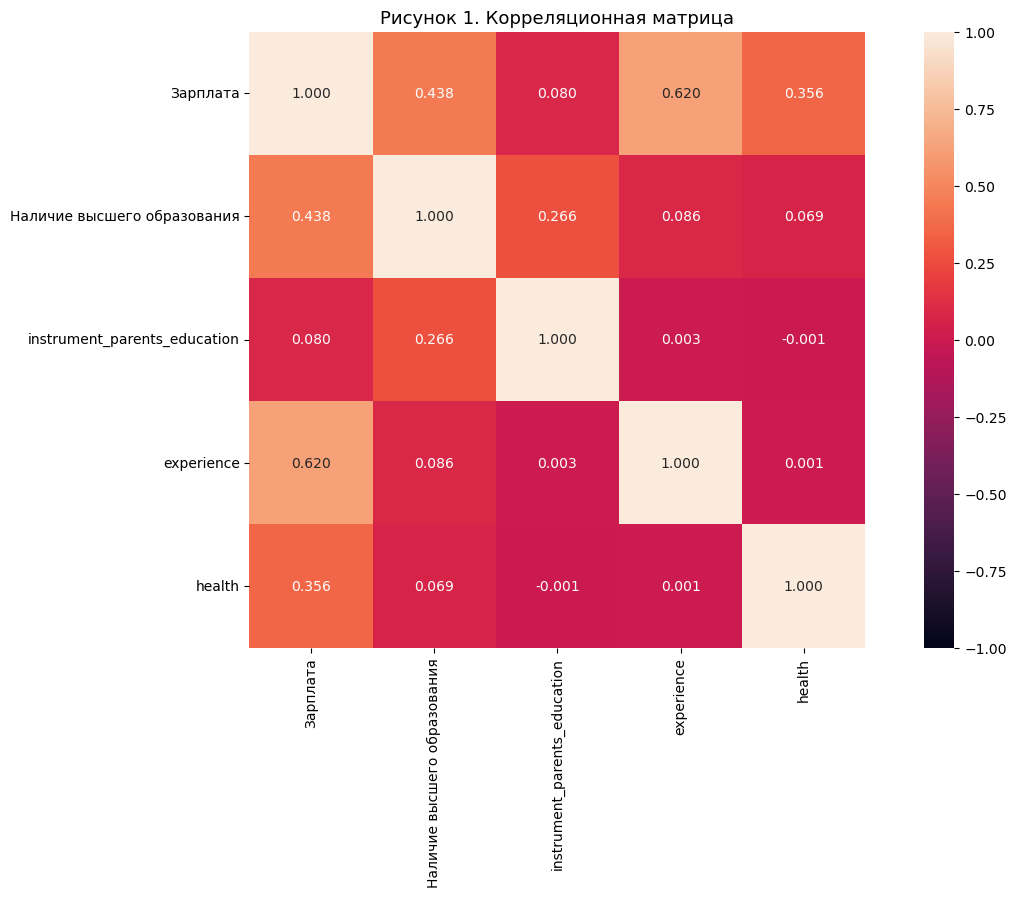

In [8]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.rename(columns={'y (wage)': 'Зарплата',
                               'D (education)': 'Наличие высшего образования'}).corr(), annot=True, vmin=-1, square=True, fmt='.3f')
plt.title(f'Рисунок 1. Корреляционная матрица', fontsize=13)
plt.show()

In [9]:
# попробуем оценить средний эффект воздействия через сравнение средних

group_means = df.groupby('D (education)')['y (wage)'].mean()
ate_naive = group_means.loc[1] - group_means.loc[0]

print(f"Наивная оценка ATE (разность средних): {ate_naive:.2f}")
print(f"Истинный ATE (из DGP): {ate_true:.2f}")
print(f"Смещение (naive − true): {ate_naive - ate_true:.2f}")

Наивная оценка ATE (разность средних): 25.20
Истинный ATE (из DGP): 17.00
Смещение (naive − true): 8.20


Теоретическое обоснование смещенности оценки, полученной через сравнение средних:

Эффект воздействия для одного наблюдения определен как разность потенциальных исходов: $Y_{i}(1)-Y_{i}(0)$. Но один из них всегда остается ненаблюдаемым, поэтому мы не сможем посчитать индивидуальный эффект воздействия и ATE. Вместо этого мы можем попытаться оценить этот эффект, используя наблюдаемые данные. Рассчитаем следующую наблюдаемую величину: $$E(Y_{i}(1)|D_{i}=1)-E(Y_{i}(0)|D_{i}=0)$$

$E(Y_{i}(1)|D_{i}=1)$ - ожидаемое значение зависимой переменной для объектов, которые подверглись воздействию.
$E(Y_{i}(0)|D_{i}=0)$ - ожидаемое значение зависимой переменной для объектов, которые не подвергались воздействию.

Чтобы выяснить, как эта разница математических ожиданий соотносится с интересующей нас величиной ATE, осуществим такие преобразования:

$$E(Y_{i}(1)|D_{i}=1)-E(Y_{i}(0)|D_{i}=0) = $$
$$E(Y_{i}(1)|D_{i}=1)-E(Y_{i}(0)|D_{i}=1)+E(Y_{i}(0)|D_{i}=1)-E(Y_{i}(0)|D_{i}=0)= $$
$$\underbrace{E(Y_{i}(1)-Y_{i}(0)|D_{i}=1)}_\text{ATET}+
\underbrace{E(Y_{i}(0)|D_{i}=1)-E(Y_{i}(0)|D_{i}=0)}_\text{selection bias}$$

$E(Y_{i}(1)-Y_{i}(0)|D_{i}=1)$ - это средний эффект воздействия для индивидов, которые подверглись воздействию (average treatment effect on the treated, ATET)

$E(Y_{i}(0)|D_{i}=1)-E(Y_{i}(0)|D_{i}=0)$ - это выражение называют смещением из-за самоотбора (selection bias). Первое слагаемое здесь — ожидаемый исход для treatment группы ($D_{i}=1$), если бы она не подверглась воздействию ($Y_{i}(0)$). Второе слагаемое — ожидаемый исход для контрольной группы при отсутствии воздействия.

Тогда исходная разность математических ожиданий может быть записана так:
$$E(Y_{i}(1)|D_{i}=1)-E(Y_{i}(0)|D_{i}=0)=ATET+selection bias$$

Если же предположить, что индивиды случайным образом распределяются между испытуемой и контрольной группой в ходе контролируемого эксперимента, то наш вывод поменяется. Действительно, в условиях случайного распределения по группам (random assignment) попадание объекта в ту или иную группу не будет зависеть от его характеристик. В терминах математических ожиданий это будет означать, что: $$E(Y_{i}(0)|D_{i}=1)=E(Y_{i}(0)|D_{i}=0)=E(Y_{i}(0))$$

В такой ситуации смещение из-за самоотбора отсутствует: $$selectionbias = E(Y_{i}(0)|D_{i}=1)-E(Y_{i}(0)|D_{i}=0)=0$$

Следовательно, разность условных математических ожиданий равна интересующему нас среднему эффекту воздействия: $$ATET=E(Y_{i}|D_{i}=1)-E(Y_{i}|D_{i}=0)$$

В нашем случае treatment не назначается случайно. Тогда $(Y(1), Y(0) \not\perp D$ из-за чего возникают эндогенность переменной воздействия, смещение из-за самоотбора и confounding, когда фактор влияет и на получение treatment и на исход.

### Классические методы для оценки эффекта воздействия 

1. Matching

__Идея:__ пытаемся приблизить наблюдения к условиям рандомизированного эксперимента за счёт формирования сопоставимых treatment и control групп. Поскольку один из потенциальных исходов для каждого объекта всегда ненаблюдаем, необходимо построить его оценку на основе информации о схожих наблюдениях из противоположной группы.

В мэтчинге для каждого объекта из treatment-группы подбираются наиболее похожие на него объекты из control-группы на основе наблюдаемых характеристик $X$. Предполагается, что после такого сопоставления различия между объектами связаны преимущественно с treatment, а не с систематическими различиями в значениях факторов. В этом случае исходы сопоставленных объектов из control-группы могут использоваться как приближённая оценка ненаблюдаемых исходов treated-объектов. Аналогичная процедура может проводиться и для объектов контрольной группы.

__Mahalanobis matching:__

Одним из классических подходов является мэтчинг на основе расстояния Махаланобиса:
$$
d(x,y)=(x-y)^T\Sigma^{-1}(x-y),
$$
где $\Sigma^{-1}$ — обратная ковариационная матрица признаков. Ближайшими считаются объекты с минимальным расстоянием между векторами характеристик. Для каждого объекта ищем ближайший к нему, но из противоположной группы. 

Однако при большом числе признаков мэтчинг по расстоянию Махаланобиса сталкивается с проблемой проклятья размерности (curse of dimensionality): становится сложно находить наблюдения, близкие сразу по всем координатам, что увеличивает смещение оценок. Кроме того, при $p$, сопоставимом с размером выборки, оценка обратной ковариационной матрицы $\Sigma^{-1}$ становится неустойчивой.

Частично проблему вычислительной сложности можно смягчить приближёнными методами поиска ближайших соседей, но это не решает проблему роста смещения с размерностью.

__Propensity score matching:__

Для решения описанной выше проблемы широко используется propensity score matching (PSM). Мера склонности (propensity score) определяется как условная вероятность получения treatment:
$$
e(X_i)=P(D_i=1|X_i).
$$
Вместо сопоставления объектов по всему вектору признаков $X$ мэтчинг осуществляется по значению propensity score. При выполнении условия unconfoundedness относительно $X$, оно также выполняется и относительно одномерного propensity score $e(X)$ — это и есть теоретическое обоснование перехода от мэтчинга по полному вектору $X$ к мэтчингу по скалярной величине. Тогда, задача сопоставления становится одномерной: исследователь сравнивает объекты не по множеству ковариат одновременно, а по вероятности получения treatment. Это существенно упрощает процедуру мэтчинга и делает её более устойчивой в высокоразмерных данных.


In [10]:
# Mahalanobis matching

from sklearn.neighbors import NearestNeighbors

X_cols = ['X1', 'X2']

X = data[X_cols].values
D = data['D'].values
Y = data['Y'].values

X_treated = X[D == 1]
X_control = X[D == 0]
Y_treated = Y[D == 1]
Y_control = Y[D == 0]

# обратная ковариационная матрица по всей выборке
cov_inv = np.linalg.inv(np.cov(X, rowvar=False))

# для каждого treated ищем ближайшего соседа из control — оценка Y(0)
nn_control = NearestNeighbors(n_neighbors=1, metric='mahalanobis', metric_params={'VI': cov_inv})
nn_control.fit(X_control)
_, idx_for_treated = nn_control.kneighbors(X_treated)
y0_hat_treated = Y_control[idx_for_treated.flatten()]

# для каждого control ищем ближайшего соседа из treated — оценка Y(1)
nn_treated = NearestNeighbors(n_neighbors=1, metric='mahalanobis', metric_params={'VI': cov_inv})
nn_treated.fit(X_treated)
_, idx_for_control = nn_treated.kneighbors(X_control)
y1_hat_control = Y_treated[idx_for_control.flatten()]

te_treated = Y_treated - y0_hat_treated
te_control = y1_hat_control - Y_control

att_mahalanobis = te_treated.mean()
ate_mahalanobis = np.concatenate([te_treated, te_control]).mean()

print(f"ATT (Mahalanobis matching): {att_mahalanobis:.2f}")
print(f"ATE (Mahalanobis matching): {ate_mahalanobis:.2f}")

ATT (Mahalanobis matching): 21.21
ATE (Mahalanobis matching): 20.97


Сделаем диагностику баланса (без неё непонятно, правда ли мэтчинг сделал группы сопоставимыми, или просто взял ближайшее что было):

In [11]:
def smd(x_t, x_c):
    return (x_t.mean() - x_c.mean()) / np.sqrt((x_t.var() + x_c.var()) / 2)

print("SMD до матчинга:")
for i, col in enumerate(X_cols):
    print(f"  {col}: {smd(X_treated[:, i], X_control[:, i]):.3f}")

X_control_matched = X_control[idx_for_treated.flatten()]
print("SMD после матчинга (treated vs подобранный control):")
for i, col in enumerate(X_cols):
    print(f"  {col}: {smd(X_treated[:, i], X_control_matched[:, i]):.3f}")

SMD до матчинга:
  X1: 0.173
  X2: 0.139
SMD после матчинга (treated vs подобранный control):
  X1: 0.000
  X2: 0.000


SMD упал с 0.181/0.137 до 0.001/0.000 — то есть по наблюдаемым X1, X2 группы после мэтчинга практически неразличимы.

In [12]:
# Propensity score matching

from sklearn.linear_model import LogisticRegression

# оцениваем propensity score
logit = LogisticRegression()
logit.fit(X, D)
propensity_score = logit.predict_proba(X)[:, 1]
data['propensity_score'] = propensity_score

ps_treated = propensity_score[D == 1].reshape(-1, 1)
ps_control = propensity_score[D == 0].reshape(-1, 1)

nn_control_ps = NearestNeighbors(n_neighbors=1)
nn_control_ps.fit(ps_control)
_, idx_for_treated_ps = nn_control_ps.kneighbors(ps_treated)
y0_hat_treated_ps = Y_control[idx_for_treated_ps.flatten()]

nn_treated_ps = NearestNeighbors(n_neighbors=1)
nn_treated_ps.fit(ps_treated)
_, idx_for_control_ps = nn_treated_ps.kneighbors(ps_control)
y1_hat_control_ps = Y_treated[idx_for_control_ps.flatten()]

te_treated_ps = Y_treated - y0_hat_treated_ps
te_control_ps = y1_hat_control_ps - Y_control

att_psm = te_treated_ps.mean()
ate_psm = np.concatenate([te_treated_ps, te_control_ps]).mean()

print(f"ATT (PSM): {att_psm:.2f}")
print(f"ATE (PSM): {ate_psm:.2f}")

# Проверим overlap
print(f"\nРазброс propensity score — treated: [{ps_treated.min():.3f}, {ps_treated.max():.3f}]")
print(f"Разброс propensity score — control: [{ps_control.min():.3f}, {ps_control.max():.3f}]")

ATT (PSM): 21.29
ATE (PSM): 20.87

Разброс propensity score — treated: [0.299, 0.710]
Разброс propensity score — control: [0.304, 0.703]


Overlap выполняется

__Наблюдения:__ И mahalanobis matching, и PSM дают примерно одинаковую, но все еще смещенную оценку эффекта, но здесь смещение меньше чем при наивном сравнении средних. Это происходит из-за ненаблюдаемого фактора abilities, который мы не можем включить в модель

2. Inverse probability weighting

Идея метода заключается в том, чтобы объекты, недопредставленные в своей группе (т.е. вероятность получить фактически наблюдаемый статус воздействия мала), получили больший вес, а объекты, чрезмерно представленные в своей группе - меньший вес. 

Вероятность получения воздействия оценивается через propensity score: $e(X_{i})=P(D_{i}=1|X_{i})$. В рамках IPW объектам из treatment-группы присваивается вес $1/e(X_{i})$, а объектам из control-группы — вес $1/(1-e(X_{i}))$. Интуитивно это означает, что больший вес получают наблюдения, которые оказались в своей фактической группе с меньшей вероятностью. Такие объекты особенно важны, поскольку они представляют недопредставленные типы наблюдений. IPW можно интерпретировать как построение псевдопопуляции, в которой распределение наблюдаемых характеристик X уже не связано с переменной воздействия $D$. Если в исходных данных treatment назначался неслучайно, то после корректного взвешивания группы treatment и control становятся более сопоставимыми по наблюдаемым факторам. При выполнении предпосылок условной независимости, overlap/positivity и consistency ассоциация между $D$ и $Y$ во взвешенной псевдопопуляции может быть интерпретирована как причинный эффект. На практике истинный propensity score неизвестен, поэтому вместо $e(X_{i})$ используется его оценка $\hat{e}(X_{i})$, полученная, например, с помощью логистической регрессии или более гибкой ML-модели. Тогда средний эффект воздействия может быть оценён как разность взвешенных средних потенциальных исходов:
$$\widehat{ATE}_{IPW}=\frac{1}{n}\sum_{i=1}^{n}\left(\frac{D_i Y_i}{\hat e(X_i)}-\frac{(1-D_i)Y_i}{1-\hat e(X_i)}\right)$$

Основное ограничение IPW связано с чувствительностью к экстремальным значениям propensity score: если $\hat{e}(X_{i})$ близок к 0 или 1, соответствующие веса становятся очень большими, что может приводить к нестабильности оценки. Поэтому в эмпирических исследованиях часто дополнительно проверяют баланс ковариат после взвешивания и используют стабилизированные веса.

In [13]:
# оценка propensity score
e_hat = data['propensity_score'].values

# базовая IPW-оценка
ate_ipw = np.mean(D * Y / e_hat - (1 - D) * Y / (1 - e_hat))
print(f"ATE (IPW): {ate_ipw:.2f}")

# веса и диагностика экстремальных значений
weights = D / e_hat + (1 - D) / (1 - e_hat)

print(f"\nВеса — min: {weights.min():.2f}, max: {weights.max():.2f}, mean: {weights.mean():.2f}")
print(f"Доля весов > 10: {(weights > 10).mean():.3f}")

ATE (IPW): 20.95

Веса — min: 1.41, max: 3.36, mean: 2.00
Доля весов > 10: 0.000


In [14]:
# стабилизационные веса

p_treated = D.mean()  # безусловная доля treated в выборке

stabilized_weights = np.where(
    D == 1,
    p_treated / e_hat,
    (1 - p_treated) / (1 - e_hat)
)

ate_ipw_stabilized = (
    np.sum(stabilized_weights * D * Y) / np.sum(stabilized_weights * D)
    - np.sum(stabilized_weights * (1 - D) * Y) / np.sum(stabilized_weights * (1 - D))
)

print(f"ATE (IPW, stabilized): {ate_ipw_stabilized:.2f}")
print(f"Стабилизированные веса — min: {stabilized_weights.min():.2f}, max: {stabilized_weights.max():.2f}")

ATE (IPW, stabilized): 20.94
Стабилизированные веса — min: 0.64, max: 1.84


In [15]:
# баланс ковариат, сравниваем взвешенные группы

def weighted_mean(x, w):
    return np.sum(w * x) / np.sum(w)

def weighted_var(x, w):
    m = weighted_mean(x, w)
    return np.sum(w * (x - m)**2) / np.sum(w)

def weighted_smd(x, d, w):
    x_t, w_t = x[d == 1], w[d == 1]
    x_c, w_c = x[d == 0], w[d == 0]
    mean_t, mean_c = weighted_mean(x_t, w_t), weighted_mean(x_c, w_c)
    var_t, var_c = weighted_var(x_t, w_t), weighted_var(x_c, w_c)
    return (mean_t - mean_c) / np.sqrt((var_t + var_c) / 2)

print("Weighted SMD после IPW:")
for i, col in enumerate(X_cols):
    print(f"  {col}: {weighted_smd(X[:, i], D, weights):.3f}")

Weighted SMD после IPW:
  X1: 0.000
  X2: 0.000


__Наблюдения:__ В данном случае оценки IPW и IPW со стабилизационными весами совпадают, но разброс весов уменьшился. Оценка эффекта все также смещенная, примерно такая же как и в мэтчинге, но все равно лучше разности средних

3. Instrumental variables

Основная идея IV заключается в использовании дополнительной переменной $Z$, называемой инструментом. Инструмент должен удовлетворять следующим условиям:
- **relevance**: инструмент должен быть связан с переменной воздействия $D$, то есть $\operatorname{Cov}(Z_i,D_i)\neq 0$;
- **exclusion restriction**: инструмент не должен напрямую влиять на исход $Y$, кроме как через воздействие $D$;
- **independence/exogeneity**: инструмент не должен быть связан с ненаблюдаемыми факторами, влияющими на исход.

Иными словами, $Z$ должен создавать внешнюю, экзогенную вариацию в treatment, которую можно использовать для оценки причинного эффекта. В простейшем случае бинарного инструмента стандартная IV-оценка может быть записана как:
$$
\hat{\tau}_{IV}
=
\frac{
E[Y_i \mid Z_i=1]-E[Y_i \mid Z_i=0]
}{
E[D_i \mid Z_i=1]-E[D_i \mid Z_i=0]
}.
$$

Числитель этой дроби отражает связь инструмента с исходом, а знаменатель — связь инструмента с переменной воздействия. Поэтому IV-оценку можно интерпретировать как эффект той части вариации в $D$, которая вызвана инструментом $Z$. При выполнении условий релевантности (инструмен связан с переменной воздействия), независимости (инструмент не зависит от характеристик наблюдения), исключающего ограничения (инструмент напрямую не оказывает влияния на зависимую переменную, только через переменную воздействия) и монотонности, то есть отсутствия индивидов типа defier, такая оценка имеет интерпретацию local average treatment effect (LATE), или среднего эффекта воздействия для compliers — объектов, чьё treatment-поведение изменяется под влиянием инструмента.

4 типа индивидов в теореме о LATE
- complier — получает treatment только если инструмент сработал ($D(0)=0, D(1)=1$)
- always-taker — получает treatment независимо от инструмента ($D(0)=D(1)=1$)
- never-taker — не получает treatment независимо от инструмента ($D(0)=D(1)=0$)
- defier — делает наоборот ($D(0)=1, D(1)=0$) — именно их отсутствие и есть монотонность

В регрессионной форме IV чаще всего реализуют через двухшаговый МНК. На первом шаге строится регрессия treatment на инструмент и ковариаты:
$$
D_i=\gamma_0+\gamma_1 Z_i+X_i^T\gamma_2+v_i.
$$

После этого во второй стадии исход объясняется предсказанной частью переменной воздействия:
$$
Y_i=\alpha+\tau \hat{D}_i+X_i^T\beta+u_i.
$$


In [16]:
data.head()

,Y,D,Z,X1,X2,propensity_score
0,177.725914,0,0,7.457838,75.575954,0.492262
1,109.641180,1,0,4.923632,48.665165,0.417706
2,121.613458,1,1,4.599888,83.792712,0.474966
3,121.004372,0,0,4.599942,76.719706,0.462615
4,157.298974,1,1,13.554017,70.147494,0.550239


In [17]:
# оценим эффект воздействия для compliers через формулу late
Y = data['Y'].values
D = data['D'].values
Z = data['Z'].values
X = data[X_cols].values  

ey_z1, ey_z0 = Y[Z == 1].mean(), Y[Z == 0].mean()
ed_z1, ed_z0 = D[Z == 1].mean(), D[Z == 0].mean()

tau = (ey_z1 - ey_z0) / (ed_z1 - ed_z0)

print(f"Cov(Z, D): {np.cov(Z, D)[0, 1]:.4f}") # проверили relevance - ковариация z и d не нулевая
print(f"IV (Wald estimator): {tau:.2f}")

Cov(Z, D): 0.0649
IV (Wald estimator): 17.30


In [18]:
# оценим late через двухшаговый мнк
import statsmodels.api as sm

# регрессия переменной воздействия на ковариаты и инструмент
X_stage1 = sm.add_constant(np.column_stack([Z, X]))  # const, Z, X1, X2
first_stage = sm.OLS(D, X_stage1).fit()
D_hat = first_stage.predict(X_stage1) 

# получаем оценку эффекта 
X_stage2 = sm.add_constant(np.column_stack([D_hat, X]))  # const, D_hat, X1, X2
second_stage = sm.OLS(Y, X_stage2).fit()

tau_2sls_manual = second_stage.params[1]  # коэффициент при D_hat
print(f"LATE 2sls: {tau_2sls_manual:.2f}")

LATE 2sls: 17.03


In [19]:
# воспользуемся готовым iv для сравнения 

from linearmodels.iv import IV2SLS

iv_data = pd.DataFrame({'Y': Y, 'D': D, 'Z': Z, 'X1': X[:, 0], 'X2': X[:, 1]})
iv_data['const'] = 1

iv_model = IV2SLS(
    dependent=iv_data['Y'],
    exog=iv_data[['const', 'X1', 'X2']],
    endog=iv_data['D'],
    instruments=iv_data['Z']
).fit()

print(iv_model.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:                      Y   R-squared:                      0.6375
Estimator:                    IV-2SLS   Adj. R-squared:                 0.6374
No. Observations:              100000   F-statistic:                 1.218e+05
Date:                Sat, Oct 03 2026   P-value (F-stat)                0.0000
Time:                        00:15:59   Distribution:                  chi2(3)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          53.222     0.2286     232.79     0.0000      52.774      53.670
X1             4.3368     0.0161     269.00     0.00

Видим, что оба метода (ручной и библиотечный) дали одинаковые оценки

__Наблюдения:__ IV очень хорошо справился с оценкой LATE (особенно через двухшаговый МНК). Оценка 2SLS очень близка к истинному LATE из DGP. Это позволяет сделать вывод о том, что при грамотно выбранном инструменте IV позволяет достаточно близко оценить LATE

### Методы машинного обучения для оценки эффектов воздействия

1. Meta-learners

Meta-learners представляют собой не отдельную идентификационную теорию причинного вывода, а общую схему построения оценки CATE поверх базовых supervised-learning моделей. Иными словами, они задают способ декомпозиции задачи оценки эффекта воздействия на последовательность задач регрессии или классификации, решаемых стандартными ML-алгоритмами. Поэтому meta-learners корректнее рассматривать не как самостоятельные методы, а как архитектуры оценивания при уже принятых идентификационных предпосылках.

__S-learner__

S-learner (Single learner) использует единую модель машинного обучения для оценки условного математического ожидания исхода в зависимости от признаков и переменной воздействия. Переменная treatment добавляется как обычный признак, после чего эффект воздействия оценивается как разница между предсказаниями модели при $D=1$ и $D=0$.
Основная идея метода заключается в том, что одна ML-модель одновременно обучается как на treated-, так и на control-наблюдениях. Однако при слабом treatment effect модель может чрезмерно регуляризовать переменную воздействия и занижать эффект практически до нуля.

In [20]:
from catboost import CatBoostRegressor

In [21]:
X_s = np.column_stack([X, D])  # X1, X2, D как обычный признак
s_learner = CatBoostRegressor(
        iterations=200,
        depth=3,
        learning_rate=0.1,
        verbose=False,
        random_state=42
    )
s_learner.fit(X_s, Y)

X_s1 = np.column_stack([X, np.ones(len(X))])
X_s0 = np.column_stack([X, np.zeros(len(X))])

cate_s = s_learner.predict(X_s1) - s_learner.predict(X_s0)
ate_s_learner = cate_s.mean()

print(f"ATE (S-learner): {ate_s_learner:.2f}")

ATE (S-learner): 20.98


__T-Learner__

T-learner (Two learner) строит две отдельные модели: одну для treated-группы и одну для control-группы. Первая оценивает зависимость исхода от признаков среди объектов с $D=1$, а вторая — среди объектов с $D=0$. После этого CATE оценивается как разница между предсказаниями этих двух моделей. 
Идея метода состоит в ослаблении проблемы регуляризации treatment-переменной, характерной для S-learner. Поскольку модели обучаются отдельно для treated и control групп, каждая из них может лучше улавливать специфическую структуру данных внутри своей подвыборки.

In [22]:
mu1 = CatBoostRegressor(
        iterations=200,
        depth=3,
        learning_rate=0.1,
        verbose=False,
        random_state=42
    )
mu0 = CatBoostRegressor(
        iterations=200,
        depth=3,
        learning_rate=0.1,
        verbose=False,
        random_state=42
    )

mu1.fit(X[D == 1], Y[D == 1])
mu0.fit(X[D == 0], Y[D == 0])

cate_t = mu1.predict(X) - mu0.predict(X)
ate_t_learner = cate_t.mean()

print(f"ATE (T-learner): {ate_t_learner:.2f}")

ATE (T-learner): 20.98


__R-Learner__

R-learner (Residual learner) основан на идее residualization (partialling-out). 

Предположим что исход можно разложить следующим образом:
$$Y_{i}=m(X_{i})+(D_{i}-e(X_{i}))\tau(X_{i})+\varepsilon_{i}$$
где $m(X_{i}) = E(y_{i}|X_{i})$; $e(X_{i})=P(D_{i}=1|X_{i})$

На первом этапе исход и воздействие очищается от влияния факторов:
$$\tilde{Y_{i}}= Y_{i}-\hat m(X_{i});  \tilde{D_{i}}= D_{i}-\hat e(X_{i})$$
Далее эффект воздействия оценивается через зависимость между полученными остатками:
$$\tilde{Y_{i}}=\tau(X_{i})\tilde{D_{i}}+\varepsilon_{i}$$
$$\hat \tau(.) = argmin \frac{1}{n}\sum_{i}(\tilde{Y_{i}}-\tau(X_{i})\tilde{D_{i}})^{2}+regularization$$

Идея partialling-out, лежащая в основе R-learner, является нелинейным обобщением классической теоремы Фриша-Воу-Ловелла: в линейном случае коэффициент при $D$ в полной регрессии $Y$ на $D$ и $X$ совпадает с коэффициентом регрессии остатков $Y$ (после "очистки" от $X$) на остатки $D$. 
R-learner расширяет эту идею, заменяя линейную проекцию на $X$ гибкими ML-моделями $\hat m(x)$ и $\hat e(x)$, а сам коэффициент — функцией $\tau(x)$, отражающей гетерогенность эффекта.

Основная идея метода заключается в том, чтобы отделить вариацию исхода, связанную именно с возздействием, от вариации, объясняемой наблюдаемыми факторами. В отличие от S- и T-learner, R-learner не пытается полностью моделировать потенциальные исходы для treated и control групп, а напрямую фокусируется на оценке CATE. Это позволяет снизить дисперсию оценки, особенно в задачах с высокоразмерными данными.

In [23]:
m = CatBoostRegressor(
        iterations=200,
        depth=3,
        learning_rate=0.1,
        verbose=False,
        random_state=42
    )
m.fit(X, Y)
m_hat = m.predict(X)

Y_tilde = Y - m_hat
D_tilde = D - e_hat

mask = np.abs(D_tilde) > 1e-3  # избегаем деления на околонулевые остатки
pseudo_outcome = Y_tilde[mask] / D_tilde[mask]
weights = D_tilde[mask] ** 2

r_learner = CatBoostRegressor(
        iterations=200,
        depth=3,
        learning_rate=0.1,
        verbose=False,
        random_state=42
    )
r_learner.fit(X[mask], pseudo_outcome, sample_weight=weights)

cate_r = r_learner.predict(X)
ate_r_learner = cate_r.mean()

print(f"ATE (R-learner): {ate_r_learner:.2f}")

ATE (R-learner): 20.94


__X-learner__

X-learner (Cross learner) представляет собой развитие T-learner для ситуаций с несбалансированными данными, когда одна из групп (treatment или control) значительно меньше другой. На первом этапе метод, как и T-learner, строит две отдельные модели для оценки исходов в treatment и control группах:
$\hat \mu_{T} = \hat E(y_{i}|X_{i}, D_{i}=1)$ и $\hat \mu_{C} = \hat E(y_{i}|X_{i}, D_{i}=0)$ 

После этого для treated- и control-объектов отдельно восстанавливаются ненаблюдаемые потенциальные исходы и вычисляются вспомогательные оценки эффекта воздействия. Ненаблюдаемые получаем через соответсвующие модели
Для treated-объектов эффект оценивается как разность между наблюдаемым исходом и предсказанным исходом без воздействия ($\tilde \tau_{i}^{1}=Y_{i}-\hat \mu_{c}(X_{i})$), а для control-объектов — как разность между предсказанным outcome при воздействии и наблюдаемым outcome без воздействия ($\tilde \tau_{i}^{0} = \hat \mu_{T}(X_{i}) - Y_{i}$). 

Далее построим модели для оценки CATE на основании полученных оценок эффектов отдельно для treatment и control выборок:
$$\hat \tau_{1}(x) = E(\tilde \tau_{i}^{1}|X=x),     \hat \tau_{0}(x) = E(\tilde \tau_{i}^{0}|X=x)$$

$\hat \tau_{1}(x)$ обучена на treated-объектах (но качество её зависит от того, насколько хорошо отработала control-модель $\hat\mu_{C}$), а $\hat \tau_{0}(x)$ — на control-объектах (зависит от качества $\hat\mu_{T}$).


На заключительном этапе обе оценки объединяются с помощью propensity score weighting.
$$\hat \tau = \hat e(x)\hat \tau_{0}(x) + (1 - \hat e(x))\hat \tau_{1}(x)$$

Интуиция метода заключается в том, что при дисбалансе групп более надежная оценка получает больший вес. Например, если группа воздействия мала, а контрольная значительно больше, то модель $\mu_{c}$ более надежна, а значит оценка $\hat \tau_{1}$ должна получить больший вес, что достигается за счет низкого propensity score, так как воздействие редкое

In [24]:
tau1_tilde = Y[D == 1] - mu0.predict(X[D == 1])
tau0_tilde = mu1.predict(X[D == 0]) - Y[D == 0]

tau1_model = CatBoostRegressor(
        iterations=200,
        depth=3,
        learning_rate=0.1,
        verbose=False,
        random_state=42
    )
tau0_model = CatBoostRegressor(
        iterations=200,
        depth=3,
        learning_rate=0.1,
        verbose=False,
        random_state=42
    )

tau1_model.fit(X[D == 1], tau1_tilde)
tau0_model.fit(X[D == 0], tau0_tilde)

cate_x = e_hat * tau0_model.predict(X) + (1 - e_hat) * tau1_model.predict(X)
ate_x_learner = cate_x.mean()

print(f"ATE (X-learner): {ate_x_learner:.2f}")

ATE (X-learner): 20.97


__Наблюдения:__ Все 4 learner'а дали примерно одинаковую смещенную оценку ATE. При этом наименее смещенная оценка у R-learner, он за счёт partialling-out менее чувствителен к регуляризационному смещению. Смещение в оценке ATE возникает, так как meta learner'ы не учитывают ненаблюдаемые факторы.

2. Causal trees

Causal tree делит выборку на подгруппы не по значениям $Y$, а по различиям в эффекте воздействия: дерево ищет такое разбиение признакового пространства, при котором treatment effect в разных листьях отличается максимально. Задача отличается от обычного supervised learning тем, что индивидуальный эффект ненаблюдаем напрямую — для каждого объекта видно либо $Y(1)$, либо $Y(0)$, но не оба исхода одновременно.

Построение дерева похоже на обычное решающее дерево — перебираются возможные split'ы по признакам $X$, но критерий выбора другой: вместо улучшения прогноза $Y$ разбиение должно улучшать оценку неоднородности эффекта.

В каждом листе $R$ treatment effect оценивается как разница средних исходов между treated и control:
$$
\hat{\tau}(R) = \frac{1}{n_{1,R}}\sum_{i \in R,\, D_i=1} Y_i - \frac{1}{n_{0,R}}\sum_{i \in R,\, D_i=0} Y_i,
$$
где $n_{1,R}$, $n_{0,R}$ — число treated- и control-наблюдений в листе.

Алгоритм выбирает split $(j, t)$ по признаку $j$ и порогу $t$, максимизируя:
$$
Q(R_m; j,t) = \frac{|R_l|}{|R_m|}\hat{\tau}^2(R_l) + \frac{|R_r|}{|R_m|}\hat{\tau}^2(R_r),
\qquad
(j,t) = \arg\max_{j,t} Q(R_m; j,t).
$$

Критерий учитывает не только различие между $\hat\tau(R_l)$ и $\hat\tau(R_r)$, но и размер дочерних узлов — это не даёт алгоритму выделять крошечные листья только из-за случайно большого эффекта внутри них.

In [25]:
#pip install causalml

In [26]:
from causalml.inference.tree import CausalTreeRegressor
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

treatment_labels = np.where(D == 1, 'treatment', 'control')

causal_tree = CausalTreeRegressor(
    control_name='control',
    max_depth=3,
    min_samples_leaf=100,       
    min_group_samples=50,   # в каждом листе должно остаться достаточно treated для надёжной оценки n_{1,R}
    random_state=42
)
causal_tree.fit(X=X, treatment=treatment_labels, y=Y)

cate_tree = causal_tree.predict(X)
ate_causal_tree = cate_tree.mean()

print(f"ATE (Causal Tree): {ate_causal_tree:.2f}")

Failed to import duecredit due to No module named 'duecredit'


ATE (Causal Tree): 23.27


Здесь сталкиваемся с классической проблемой единичного дерева - дерево обладает высоким разбросом и переобучается как черт. К тому же здесь мы снова не учитываем ненаблюдаемые факторы - abilities. Отсюда и смещение в оценке ATE 

Causal forest — ансамбль causal trees: вместо одного дерева строится много, их оценки усредняются. Мотивация та же, что и при переходе от decision tree к random forest — одно дерево нестабильно (небольшое изменение данных меняет структуру разбиений и оценки эффекта), а усреднение по ансамблю снижает variance и даёт более устойчивую оценку CATE.

Wager и Athey описывают causal forest как непараметрический метод оценки heterogeneous treatment effects, расширяющий random forest на задачу причинного вывода: при выполнении unconfoundedness он позволяет состоятельно оценивать $\tau(x) = E[Y(1) - Y(0) \mid X=x]$.

Алгоритм строит много causal trees на случайных подвыборках данных и случайных подмножествах признаков. Для нового объекта $x$ каждое дерево определяет лист, в который он попадает, и внутри этого листа оценивается локальный treatment effect; оценки по всем деревьям усредняются.

Эквивалентная интерпретация — через forest weights: для объекта $x$ строятся веса $\alpha_i(x)$, отражающие, как часто наблюдение $i$ оказывается в одном листе с $x$ по деревьям леса. Чем чаще — тем больше вес, и CATE оценивается как локальная взвешенная оценка treatment effect.

Как и для отдельного дерева, часто используется honest-подход: одна часть данных используется для построения структуры деревьев, другая — для оценки treatment effect в листьях, что снижает переобучение.

In [27]:
from econml.grf import CausalForest

causal_forest = CausalForest(
    n_estimators=500,
    min_samples_leaf=10,
    honest=True,          
    random_state=42,
    n_jobs=-1
)
causal_forest.fit(X, D, Y)

cate_forest = causal_forest.predict(X).flatten()
ate_causal_forest = cate_forest.mean()

print(f"ATE (Causal Forest): {ate_causal_forest:.2f}")

ATE (Causal Forest): 21.03


Аналогично классическому случайному лесу, causal forest снижает разброс оценки отдельных деревьев за счёт усреднения — именно это уменьшило итоговое отклонение оценки (с ~24 до ~21) по сравнению с единичным деревом. При этом смещение из-за abilities (ненаблюдаемого confounder'а) усреднением не устраняется — оно одинаково присутствует что в дереве, что в лесу, просто в дереве смешивалось с шумом.

3. Double ML

Double Machine Learning (DML), предложенный Виктором Черножуковым и соавторами, представляет собой подход, объединяющий методы машинного обучения и классический эконометрический вывод для оценивания причинных и структурных параметров в high-dimensional settings. Основная идея метода заключается в том, что часть модели, не представляющая непосредственного содержательного интереса для исследователя, например сложные зависимости между признаками, оценивается с помощью методов машинного обучения, тогда как целевой параметр, чаще всего коэффициент при переменной воздействия, оценивается с использованием специальных ортогональных moment conditions. Таким образом, DML сочетает гибкие методы машинного обучения для оценки сложных вспомогательных функций и строгий эконометрический вывод: состоятельность, асимптотическую нормальность и построение доверительных интервалов для causal parameter.

Рассмотрим частично линейную модель (Partially linear model):
$$Y_{i}=\tau D_{i}+g(X_{i})+u_{i},$$
где $E(u_{i}|X_{i}, D_{i})=0$, $g(X_{i})$ - произвольная функция, $T_{i}$ - переменная воздействия, $\tau$ - параметр интереса, $u_{i}$ - случайная ошибка.

Данная модель линейна по переменной воздействия $D_i$, однако функция $g(X_i)$ может иметь сложную нелинейную структуру. В таком случае простая линейная параметрическая спецификация, например МНК, может некорректно описывать зависимость между исходом и значениями фактров. Методы машинного обучения позволяют более гибко аппроксимировать функцию $g(X_i)$, однако их прямое использование в регрессионном анализе может приводить к смещённым оценкам параметра $\tau$ из-за смещения из-за регуляризации и переобучения.

Чтобы оценить чистый эффект $D$ на $Y$ воспользуемся идеей Фриша-Воу-Ловелла. Теорема FWL говорит, что оценка коеффициента в множественной регрессии совпадает с оценкой в парной регрессии, если $Y$ и переменную интереса предварительно очистить от влияния остальных факторов.

Возьмем условоное математическое ожидание от обеих частей по $X$ (остальные факторы) и вычтем их из исходного выражения:
$$Y_{i} - E(Y_{i}|X_{i})=\tau (D_{i}-E(D_{i}|X_{i}))+(g(X_{i}) - E(g(X_{i})|X_{i})+(u_{i} - E(u_{i} | X_{i}),$$
где:
- $E(D|X)$- какая часть treatment объясняется наблюдаемыми факторами
- $E(Y|X)$- какая часть outcome объясняется наблюдаемыми факторами
Их мы никогда не знаем точно, поэтому оценивваем их с помощью ML, которые помогут учесть сложные нелинейные зависимости. 

Так как:
$E(g(X_i)|X_i)=g(X_i)$, а из предположения модели следует: $E(u_i|X_i)=0$

В итоге получаем регрессию вида: $Y_{i}-E(Y_{i}|X_{i})=\alpha (T_{i}-E(D_{i}|X_{i}))+u_{i}$. И чтобы получить оценку параметра интереса - $\alpha$ - достаточно оценить регрессию без константы через МНК. 

Тогда оценка параметра интереса имеет следующий вид:
$$
\hat{\tau} =
\frac{
\sum_{i=1}^{n}
\left(Y_i - \hat{E}(Y_i \mid X_i)\right)
\left(D_i - \hat{E}(D_i \mid X_i)\right)
}{
\sum_{i=1}^{n}
\left(D_i - \hat{E}(D_i \mid X_i)\right)^2
}.
$$

Для снижения чувствительности оценки параметра $\tau$ к ошибкам оценок условных мат. ожиданий используется условие ортогональности по Нейману (Neyman orthogonality). В таком случае, даже если $E(D|X)$ и $E(Y|X)$ оценены не идеально, небольшие ошибки в этих функциях не должны сильно смещать оценку параметра при переменной воздействия. Подробнее об этом можно почитать в оргигинальной статье [Черножукова и соавторов](https://arxiv.org/abs/1608.00060)

Однако одной ортогональности недостаточно. Если условные мат. ожидания обучаются и применяются на одних и тех же наблюдениях, может возникнуть переобучение, что приводит к смещению оценок параметра при переменной воздействия. Для решения этой проблемы применяется cross-fitting.

При cross-fitting выборка разбивается на $K$ частей. Для каждого блока nuisance functions оцениваются на всех остальных частях выборки, а затем используются для построения прогнозов на отложенном блоке. Обозначим через $q_i$ номер блока, в который попало наблюдение $i$. Тогда для наблюдения $i$ используются только такие оценки $E(Y|X)$ и $E(D|X)$, которые были обучены без использования этого наблюдения.

В таком случае DML-оценка с cross-fitting имеет вид:
$$
\hat{\alpha}=
\frac{
\sum_{i=1}^{n}
\left(Y_i-\hat g_Y^{(q_i)}(X_i)\right)
\left(T_i-\hat g_D^{(q_i)}(X_i)\right)
}{
\sum_{i=1}^{n}
\left(T_i-\hat g_D^{(q_i)}(X_i)\right)^2
},
$$
где 
- $g_Y^{(q_i)}(X_i) = E(Y|X)$ 
- $g_D^{(q_i)}(X_i) = E(D|X)$ 
- $\hat g_Y^{(q_i)}$ и $\hat g_T^{(q_i)}$ — оценки условных мат. ожиданий, обученные без использования наблюдений из блока $q_i$.

In [28]:
# реализация вручную
from catboost import CatBoostRegressor, CatBoostClassifier
from sklearn.model_selection import KFold

K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# инициируем вектора для оценок
g_Y_hat = np.zeros(len(Y))
g_D_hat = np.zeros(len(D))

for train_idx, test_idx in kf.split(X):
    model_y = CatBoostRegressor(iterations=400, depth=8, verbose=False, random_state=42)
    model_y.fit(X[train_idx], Y[train_idx])
    g_Y_hat[test_idx] = model_y.predict(X[test_idx])

    model_d = CatBoostClassifier(iterations=400, depth=8, verbose=False, random_state=42)
    model_d.fit(X[train_idx], D[train_idx])
    g_D_hat[test_idx] = model_d.predict_proba(X[test_idx])[:, 1]

# Применим FWL
Y_tilde = Y - g_Y_hat
D_tilde = D - g_D_hat

tau_dml = np.sum(Y_tilde * D_tilde) / np.sum(D_tilde ** 2)
print(f"DML (ручной, cross-fitting K={K}): tau = {tau_dml:.2f}")

DML (ручной, cross-fitting K=5): tau = 20.96


In [29]:
model_y_full = CatBoostRegressor(iterations=400, depth=8, verbose=False, random_state=42)
model_y_full.fit(X, Y)
model_d_full = CatBoostClassifier(iterations=400, depth=8, verbose=False, random_state=42)
model_d_full.fit(X, D)

Y_tilde_nf = Y - model_y_full.predict(X)
D_tilde_nf = D - model_d_full.predict_proba(X)[:, 1]
tau_no_crossfit = np.sum(Y_tilde_nf * D_tilde_nf) / np.sum(D_tilde_nf ** 2)

print(f"DML (без cross-fitting): tau = {tau_no_crossfit:.2f}")

DML (без cross-fitting, nuisance на тех же данных): tau = 20.91


In [30]:
#!pip install --upgrade catboost

In [32]:
# pip install doubleml
from doubleml import DoubleMLData, DoubleMLPLR
from catboost import CatBoostRegressor, CatBoostClassifier

df_dml = pd.DataFrame({'Y': Y, 'D': D, 'X1': X[:, 0], 'X2': X[:, 1]})
data_dml = DoubleMLData(df_dml, y_col='Y', d_cols='D', x_cols=X_cols)

ml_g = CatBoostRegressor(iterations=400, depth=8, verbose=False, random_state=42)
ml_m = CatBoostClassifier(iterations=400, depth=8, verbose=False, random_state=42)

plr_model = DoubleMLPLR(data_dml, ml_g, ml_m, n_folds=5)
plr_model.fit()

print(plr_model.summary)

tau_dml_doubleml = plr_model.coef[0]
ci_lower, ci_upper = plr_model.confint().values[0]

print(f"\nDML (doubleml.DoubleMLPLR): tau = {tau_dml_doubleml:.2f}")
print(f"95% CI для tau: [{ci_lower:.2f}, {ci_upper:.2f}]")

        coef   std err           t  P>|t|      2.5 %     97.5 %
D  20.973023  0.108236  193.772123    0.0  20.760886  21.185161

DML (doubleml.DoubleMLPLR): tau = 20.97
95% CI для tau: [20.76, 21.19]


__Выводы:__ Так Matching, IPW, meta-learners, causal forest и DML — все опираются на одну и ту же предпосылку: unconfoundedness относительно наблюдаемых $X$, которая нарушена. Ни один из них не видит Abilities. Отсюда и возникает смещение, но оно все же не такое большое, как при банальном сравнении средних. Единственное исключение — единичный causal tree: там к этому же confounding-смещению добавляется ещё и высокий разброс от переобученного $\hat\tau^2$-критерия, из-за чего итоговая оценка оказывается на уровне naive или хуже; именно поэтому в разделе про causal forest усреднение по ансамблю дало заметное улучшение.

IV — единственный метод из рассмотренных, который использует другие преппосылки (relevance/exclusion/independence инструмента), а не unconfoundedness. Инструмент - Parents_educ - по построению не связан с Abilities, поэтому IV обходит confounding, которое для всех остальных методов непреодолимо в принципе. Чтобы это исправить нужно включать конфаундеры, которые могут быть прокси переменными к ненаблюдаемым факторам

Чтобы снизить это смещение, можно включать наблюдаемые прокси-переменные, коррелирующие с ненаблюдаемыми факторами  — это не устраняет confounding полностью, но может существенно сократить его, если прокси достаточно информативен.